In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# AI for Digital Education (VNICT 2026)

**Integrate advanced sentiment analysis logic and tokenization processes using the Hugging Face library.**


In [ ]:
# ---------------------------------------------------------
# English: PART 0 - Suppress System Warnings & Logs
# Tiếng Việt: PHẦN 0 - Chặn các cảnh báo hệ thống và Log thừa
# ---------------------------------------------------------
import os
import logging
import warnings

# English: Set TF log level to suppress CUDA registration warnings
# Tiếng Việt: Thiết lập mức độ log của TensorFlow để ẩn các cảnh báo đăng ký CUDA
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# English: Suppress Python and Transformers warnings
# Tiếng Việt: Ẩn các cảnh báo từ Python và thư viện Transformers
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# ---------------------------------------------------------
# English: Import necessary libraries
# Tiếng Việt: Import các thư viện cần thiết
# ---------------------------------------------------------
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, pipeline

# ---------------------------------------------------------
# English: Step 1 - Create synthetic dataset for Digital Education
# Tiếng Việt: Bước 1 - Tạo dataset giả lập cho Giáo dục số
# ---------------------------------------------------------
texts = [
    "AI in education is transforming learning.",
    "Machine learning helps analyze big data.",
    "Natural language processing enables chatbots.",
    "Cybersecurity is crucial in digital society.",
    "Virtual reality enhances multimedia experiences.",
    "The AI course was amazing and very practical!",
    "I found the digital education materials a bit confusing.",
    "The online platform is slow and hard to navigate."
]

# English: Example categories (0-7) | Tiếng Việt: Ví dụ nhãn phân loại
labels = [0, 1, 2, 3, 4, 5, 6, 7] 

df = pd.DataFrame({"text": texts, "label": labels})
print("--- Dataset Preview / Xem trước dữ liệu ---")
print(df.head())

# ---------------------------------------------------------
# English: Step 2 - Convert to HuggingFace Dataset
# Tiếng Việt: Bước 2 - Chuyển sang Dataset của HuggingFace
# ---------------------------------------------------------
dataset = Dataset.from_pandas(df)

# ---------------------------------------------------------
# English: Step 3 - Tokenize dataset using a Transformer model (BERT)
# Tiếng Việt: Bước 3 - Tokenize dataset bằng mô hình Transformer (BERT)
# ---------------------------------------------------------
# English: Use 'bert-base-uncased' for general purpose text processing
# Tiếng Việt: Sử dụng 'bert-base-uncased' để xử lý văn bản tổng quát
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

# English: Apply tokenization to the entire dataset
# Tiếng Việt: Áp dụng tokenize cho toàn bộ bộ dữ liệu
# tokenized_dataset = dataset.map(tokenize_function, batched=True, verbose=False)
tokenized_dataset = dataset.map(tokenize_function, batched=True)

print("\n--- Tokenized Sample (Index 0) / Mẫu dữ liệu đã tokenize (Vị trí 0) ---")
print(tokenized_dataset[0])

# ---------------------------------------------------------
# English: Step 4 - Perform Sentiment Analysis on Education Feedback
# Tiếng Việt: Bước 4 - Thực hiện phân tích cảm xúc trên phản hồi giáo dục
# ---------------------------------------------------------
# English: Using a specialized pre-trained model for sentiment
# Tiếng Việt: Sử dụng mô hình chuyên biệt đã huấn luyện sẵn để phân tích cảm xúc
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english",
                      device=-1) # device=-1 ép chạy trên CPU để sạch log

print("\n--- Sentiment Analysis Results / Kết quả phân tích cảm xúc ---")
results = classifier(texts)

for i, res in enumerate(results):
    print(f"Text: {texts[i]}")
    print(f"Label: {res['label']} | Score: {res['score']:.4f}")
    print("-" * 20)

for i, res in enumerate(results):
    print(f"[{i+1}] Feedback: {texts[i]}")
    print(f"    Verdict: {res['label']} | Confidence: {res['score']:.4f}")
    print("-" * 50)

In [ ]:
# ---------------------------------------------------------
# English: PART 5 - Multi-sentence Sentiment Analysis (Paragraph Level)
# Tiếng Việt: PHẦN 5 - Phân tích cảm xúc đoạn văn (Nhiều câu)
# ---------------------------------------------------------

import nltk
from transformers import pipeline

# English: Download sentence tokenizer
# Tiếng Việt: Tải bộ công cụ tách câu
nltk.download('punkt', quiet=True)
from nltk.tokenize import sent_tokenize

# English: Define a long feedback paragraph (3-4 sentences)
# Tiếng Việt: Định nghĩa một đoạn phản hồi dài (3-4 câu)
long_feedback = (
    "The AI for Digital Education course is truly eye-opening and the mentors are very supportive. "
    "However, the online lab environment sometimes crashes when we run heavy simulations. "
    "Despite the technical glitches, the overall learning value is exceptional. "
    "I highly recommend this program to anyone interested in EdTech."
)

# English: Initialize the sentiment pipeline
# Tiếng Việt: Khởi tạo pipeline phân tích cảm xúc
classifier = pipeline("sentiment-analysis", 
                      model="distilbert-base-uncased-finetuned-sst-2-english",
                      device=-1)

# English: 1. Analyze the paragraph as a whole
# Tiếng Việt: 1. Phân tích toàn bộ đoạn văn cùng lúc
overall_result = classifier(long_feedback)[0]

# English: 2. Analyze sentence by sentence for deeper insight
# Tiếng Việt: 2. Phân tích từng câu để có cái nhìn chi tiết hơn
sentences = sent_tokenize(long_feedback)
sentence_results = classifier(sentences)

print("--- Paragraph Sentiment Analysis / Phân tích cảm xúc đoạn văn ---")
print(f"\nFull Text: {long_feedback}")
print(f"\nOVERALL VERDICT: {overall_result['label']} (Score: {overall_result['score']:.4f})")
print("-" * 60)

print("DETAILED BREAKDOWN (Sentence by Sentence):")
# Tiếng Việt: CHI TIẾT TỪNG CÂU:
for i, (sentence, res) in enumerate(zip(sentences, sentence_results)):
    print(f"Sentence {i+1}: {sentence}")
    print(f" >> Result: {res['label']} | Confidence: {res['score']:.4f}")
    print("-" * 30)

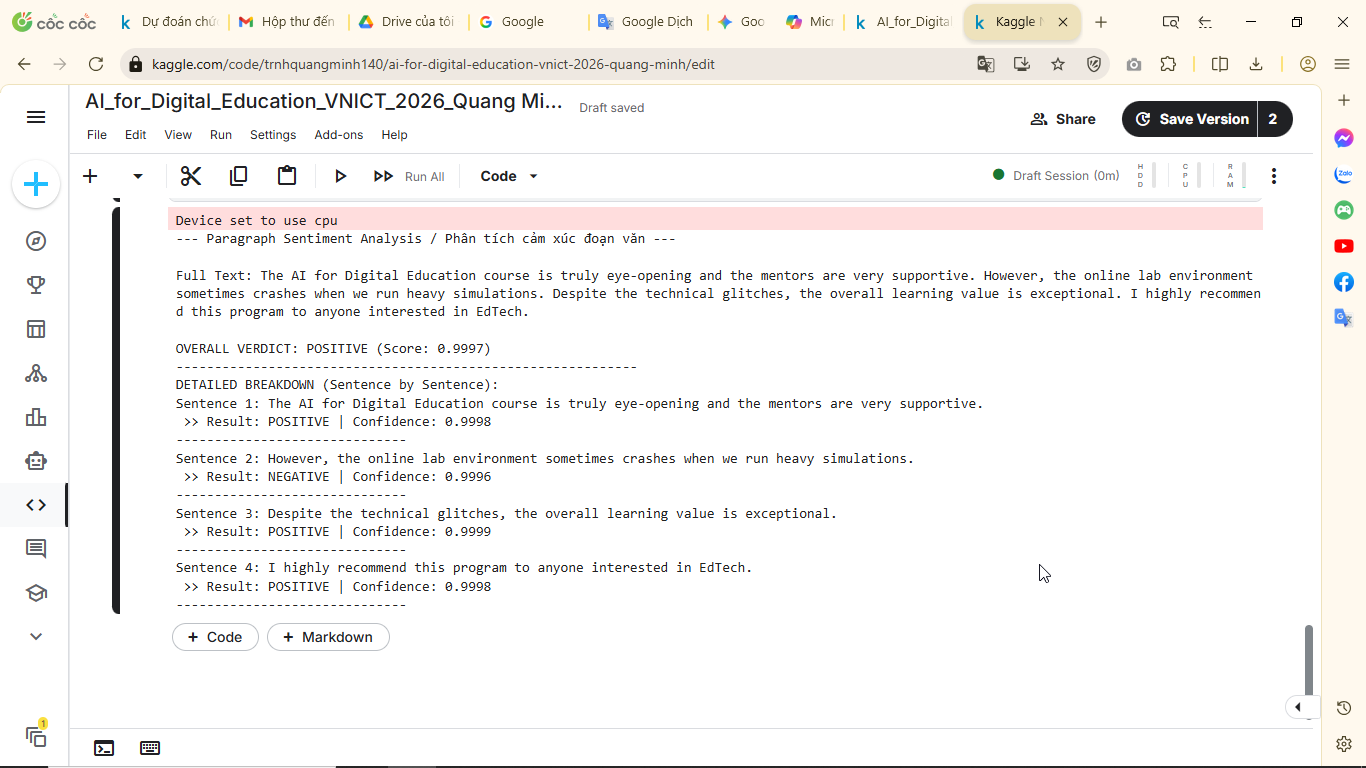

In [ ]:
# ---------------------------------------------------------
# English: PART 5 - Paragraph-Level Sentiment Analysis (Final Update)
# Tiếng Việt: PHẦN 5 - Phân tích cảm xúc cấp độ đoạn văn (Cập nhật cuối cùng)
# ---------------------------------------------------------

from transformers import pipeline

# English: Define a single paragraph as a unified text block
# Tiếng Việt: Định nghĩa một đoạn văn duy nhất như một khối văn bản thống nhất
long_feedback_paragraph = (
    "The AI for Digital Education course is truly eye-opening and the mentors are very supportive. "
    "However, the online lab environment sometimes crashes when we run heavy simulations. "
    "Despite the technical glitches, the overall learning value is exceptional. "
    "I highly recommend this program to anyone interested in EdTech."
)

# English: Initialize the sentiment classifier (using DistilBERT)
# Tiếng Việt: Khởi tạo bộ phân loại cảm xúc (sử dụng DistilBERT)
classifier = pipeline("sentiment-analysis", 
                      model="distilbert-base-uncased-finetuned-sst-2-english",
                      device=-1)  # English: force CPU | Tiếng Việt: Ép chạy trên CPU

# ---------------------------------------------------------
# English: Perform Sentiment Analysis on the whole block at once
# Tiếng Việt: Thực hiện phân tích cảm xúc trên toàn bộ khối văn bản cùng lúc
# ---------------------------------------------------------
# English: We pass the string directly to ensure the model evaluates the entire context
# Tiếng Việt: Chúng ta truyền trực tiếp chuỗi văn bản để đảm bảo mô hình đánh giá toàn bộ ngữ cảnh
result = classifier(long_feedback_paragraph)[0]

# ---------------------------------------------------------
# English: Display the Final Result
# Tiếng Việt: Hiển thị kết quả cuối cùng
# ---------------------------------------------------------
print("--- Paragraph Sentiment Analysis / Phân tích cảm xúc đoạn văn ---")
print(f"\n[TEXT CONTENT]: \"{long_feedback_paragraph}\"")
print("-" * 70)
print(f"FINAL VERDICT: {result['label']}")
print(f"CONFIDENCE SCORE: {result['score']:.4f}")
print("-" * 70)

# English: Quick Interpretation
# Tiếng Việt: Giải thích nhanh
if result['label'] == 'POSITIVE':
    print("Interpretation: The overall feedback is favorable despite some mentioned issues.")
    # Tiếng Việt: Giải thích: Phản hồi tổng thể là tích cực bất chấp một vài vấn đề đã nêu.
else:
    print("Interpretation: The overall feedback trends towards negative concerns.")
    # Tiếng Việt: Giải thích: Phản hồi tổng thể có xu hướng tiêu cực hoặc lo ngại.

In [ ]:
# ---------------------------------------------------------
# English: PART 5 - Paragraph-Level Sentiment Analysis (Comparison)
# Tiếng Việt: PHẦN 5 - Phân tích cảm xúc đoạn văn (So sánh đối chứng)
# ---------------------------------------------------------

from transformers import pipeline

# English: 1. Positive Paragraph (Mixed but generally good)
# Tiếng Việt: 1. Đoạn văn tích cực (Có ý kiến trái chiều nhưng tổng thể tốt)
positive_feedback = (
    "The AI for Digital Education course is truly eye-opening and the mentors are very supportive. "
    "However, the online lab environment sometimes crashes when we run heavy simulations. "
    "Despite the technical glitches, the overall learning value is exceptional. "
    "I highly recommend this program to anyone interested in EdTech."
)

# English: 2. Negative Paragraph (Entirely critical)
# Tiếng Việt: 2. Đoạn văn tiêu cực (Hoàn toàn là lời phê bình)
negative_feedback = (
    "I am extremely disappointed with this digital education platform. "
    "The video lectures are outdated and the audio quality is very poor. "
    "Furthermore, the technical support team never replied to my urgent inquiries. "
    "It was a complete waste of time and money."
)

# English: Initialize the sentiment classifier
# Tiếng Việt: Khởi tạo bộ phân loại cảm xúc
classifier = pipeline("sentiment-analysis", 
                      model="distilbert-base-uncased-finetuned-sst-2-english",
                      device=-1)

# English: Store paragraphs in a list for comparison
# Tiếng Việt: Lưu các đoạn văn vào danh sách để so sánh
test_paragraphs = [positive_feedback, negative_feedback]
results = classifier(test_paragraphs)

# ---------------------------------------------------------
# English: Display the Comparison Results
# Tiếng Việt: Hiển thị kết quả so sánh
# ---------------------------------------------------------
print("--- Paragraph Sentiment Comparison / So sánh cảm xúc đoạn văn ---")
print("=" * 80)

for i, res in enumerate(results):
    status = "TÍCH CỰC (POSITIVE)" if i == 0 else "TIÊU CỰC (NEGATIVE)"
    print(f"EXAMPLE {i+1} - {status}:")
    print(f"Content: \"{test_paragraphs[i]}\"")
    print(f"\n>> RESULT: {res['label']} | SCORE: {res['score']:.4f}")
    
    # English: Quick Interpretation
    # Tiếng Việt: Giải thích nhanh
    if res['label'] == 'POSITIVE':
        print("Verdict: The model captured the overall satisfaction despite minor complaints.")
        # Giải thích: Mô hình nắm bắt được sự hài lòng tổng thể bất chấp các phàn nàn nhỏ.
    else:
        print("Verdict: The model correctly identified the strong negative sentiment.")
        # Giải thích: Mô hình đã xác định chính xác sắc thái tiêu cực mạnh mẽ.
    
    print("-" * 80)

In [ ]:
# ---------------------------------------------------------
# English: PART 5 - Paragraph-Level Sentiment Analysis (Final Update)
# Tiếng Việt: PHẦN 5 - Phân tích cảm xúc cấp độ đoạn văn (Cập nhật cuối cùng)
# ---------------------------------------------------------

from transformers import pipeline

# English: Define a positive/neutral mixed feedback paragraph
# Tiếng Việt: Định nghĩa một đoạn phản hồi tích cực/pha trộn
long_feedback_paragraph = (
    "The AI for Digital Education course is truly eye-opening and the mentors are very supportive. "
    "However, the online lab environment sometimes crashes when we run heavy simulations. "
    "Despite the technical glitches, the overall learning value is exceptional. "
    "I highly recommend this program to anyone interested in EdTech."
)

# English: Define a fully negative feedback paragraph
# Tiếng Việt: Định nghĩa một đoạn phản hồi hoàn toàn tiêu cực
negative_feedback_paragraph = (
    "The online education platform is extremely slow and often crashes during important lessons. "
    "The study materials are confusing and poorly organized. "
    "Technical support is unresponsive and fails to solve issues. "
    "Overall, the experience is frustrating and disappointing."
)

# English: Initialize the sentiment classifier (using DistilBERT)
# Tiếng Việt: Khởi tạo bộ phân loại cảm xúc (sử dụng DistilBERT)
classifier = pipeline("sentiment-analysis", 
                      model="distilbert-base-uncased-finetuned-sst-2-english",
                      device=-1)

# ---------------------------------------------------------
# English: Perform Sentiment Analysis on both paragraphs
# Tiếng Việt: Thực hiện phân tích cảm xúc trên cả hai đoạn văn
# ---------------------------------------------------------
result_positive = classifier(long_feedback_paragraph)[0]
result_negative = classifier(negative_feedback_paragraph)[0]

# ---------------------------------------------------------
# English: Display the Final Results
# Tiếng Việt: Hiển thị kết quả cuối cùng
# ---------------------------------------------------------
print("--- Paragraph Sentiment Analysis / Phân tích cảm xúc đoạn văn ---")

print("\n[POSITIVE/NEUTRAL MIXED FEEDBACK]:")
print(f"\"{long_feedback_paragraph}\"")
print(f"FINAL VERDICT: {result_positive['label']} | CONFIDENCE: {result_positive['score']:.4f}")
print("-" * 70)

print("\n[NEGATIVE FEEDBACK]:")
print(f"\"{negative_feedback_paragraph}\"")
print(f"FINAL VERDICT: {result_negative['label']} | CONFIDENCE: {result_negative['score']:.4f}")
print("-" * 70)


In [ ]:
# English: Import necessary libraries
# Tiếng Việt: Import các thư viện cần thiết
import pandas as pd

# English: Define the file path to the uploaded dataset
# Tiếng Việt: Khai báo đường dẫn tới file dataset đã upload
file_path = '/kaggle/input/learner-feedback-classification-labels-07/Learner Feedback Classification Labels (07) - VNICT_2026_Minh.xlsx'

# English: Read the Excel file into a DataFrame
# Tiếng Việt: Đọc file Excel vào DataFrame
df = pd.read_excel(file_path, sheet_name="Sheet1")

# English: Display the first rows of the dataset
# Tiếng Việt: Hiển thị vài dòng đầu tiên của dataset
print(" --- Dataset Preview / Xem trước dữ liệu --- ")
print(df.head(10))

# English: Show basic info about dataset structure
# Tiếng Việt: Hiển thị thông tin cấu trúc dataset
print("\n --- Dataset Info / Thông tin dataset --- ")
print(df.info())

# English: Show summary statistics (only for numeric columns like Label)
# Tiếng Việt: Hiển thị thống kê mô tả (chỉ cho cột số như Label)
print("\n --- Dataset Statistics / Thống kê dataset --- ")
print(df.describe())

# English: Display unique categories and sample feedback
# Tiếng Việt: Hiển thị các nhãn phân loại và ví dụ phản hồi
print("\n --- Categories and Sample Feedback / Các nhãn và phản hồi mẫu --- ")
for idx, row in df.iterrows():
    print(f"Label {row['Label']} - {row['Category']}: {row['Sample Student Feedback']}")


In [ ]:
# English: Import visualization libraries
# Tiếng Việt: Import thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# English: Count the frequency of each label
# Tiếng Việt: Đếm tần suất xuất hiện của từng nhãn
label_counts = df['Label'].value_counts().sort_index()

# English: Plot bar chart of label distribution
# Tiếng Việt: Vẽ biểu đồ cột phân bố nhãn
plt.figure(figsize=(8,5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

plt.title("Distribution of Learner Feedback Labels (0–7)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(range(8), df['Category'], rotation=45, ha="right")

plt.show()


In [ ]:
# ============================================================
# English: Import necessary libraries
# Tiếng Việt: Import các thư viện cần thiết
# ============================================================
import nltk
from transformers import pipeline

# English: Download sentence tokenizer for splitting text
# Tiếng Việt: Tải bộ công cụ tách câu để chia đoạn văn
nltk.download('punkt', quiet=True)
from nltk.tokenize import sent_tokenize

# ============================================================
# English: Define mapping from POSITIVE/NEGATIVE to 0–7 scale
# Tiếng Việt: Định nghĩa ánh xạ từ POSITIVE/NEGATIVE sang thang 0–7
# ============================================================
sentiment_to_label = {
    "NEGATIVE": 0,  # Strongly Dissatisfied
    "POSITIVE": 7   # Promoting
}

label_descriptions = {
    0: "Strongly Dissatisfied",
    1: "Dissatisfied",
    2: "Confused",
    3: "Neutral / Suggestive",
    4: "Inquisitive",
    5: "Satisfied",
    6: "Very Satisfied",
    7: "Promoting"
}

# ============================================================
# English: Initialize Hugging Face sentiment analysis pipeline
# Tiếng Việt: Khởi tạo pipeline phân tích cảm xúc của Hugging Face
# ============================================================
classifier = pipeline("sentiment-analysis",
                      model="distilbert-base-uncased-finetuned-sst-2-english",
                      device=-1)  # force CPU

# ============================================================
# English: Define a long feedback paragraph (3–4 sentences)
# Tiếng Việt: Định nghĩa một đoạn phản hồi dài (3–4 câu)
# ============================================================
long_feedback = (
    "The AI for Digital Education course is truly eye-opening and the mentors are very supportive. "
    "However, the online lab environment sometimes crashes when we run heavy simulations. "
    "Despite the technical glitches, the overall learning value is exceptional. "
    "I highly recommend this program to anyone interested in EdTech."
)

# ============================================================
# English: 1. Analyze the whole paragraph
# Tiếng Việt: 1. Phân tích toàn bộ đoạn văn
# ============================================================
overall_result = classifier(long_feedback)[0]
overall_label = sentiment_to_label[overall_result['label']]

print(" --- Paragraph Sentiment Analysis / Phân tích cảm xúc đoạn văn --- ")
print(f"\nFull Text: {long_feedback}")
print(f"\nOVERALL VERDICT: {overall_result['label']} "
      f"(Score: {overall_result['score']:.4f})")
print(f"Mapped Label: {overall_label} - {label_descriptions[overall_label]}")
print("-" * 70)

# ============================================================
# English: 2. Analyze sentence by sentence for deeper insight
# Tiếng Việt: 2. Phân tích từng câu để có cái nhìn chi tiết hơn
# ============================================================
sentences = sent_tokenize(long_feedback)
sentence_results = classifier(sentences)

print("DETAILED BREAKDOWN (Sentence by Sentence):")
for i, (sentence, res) in enumerate(zip(sentences, sentence_results)):
    mapped_label = sentiment_to_label[res['label']]
    print(f"Sentence {i+1}: {sentence}")
    print(f" >> Result: {res['label']} | Confidence: {res['score']:.4f}")
    print(f" >> Mapped Label: {mapped_label} - {label_descriptions[mapped_label]}")
    print("-" * 30)


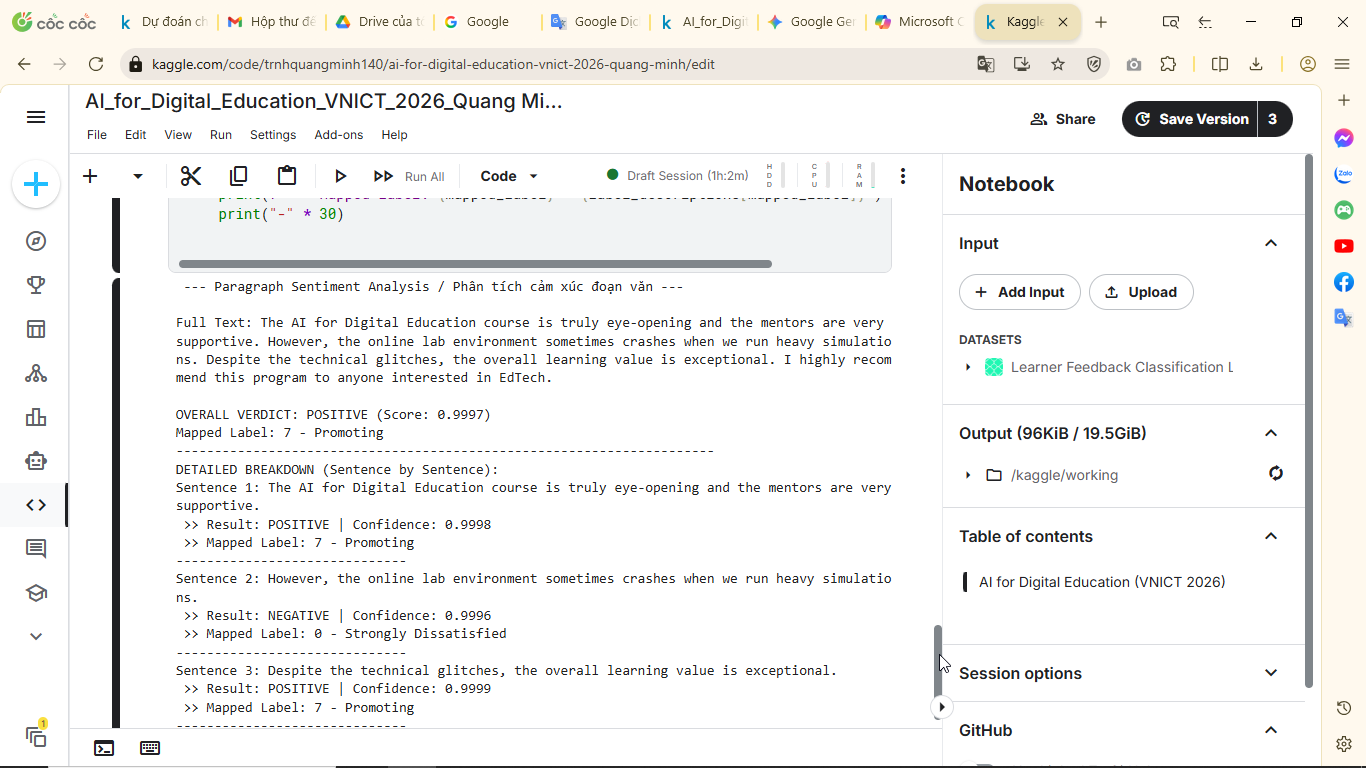

label_descriptions = {

    0: "Strongly Dissatisfied",
    
    1: "Dissatisfied",
    
    2: "Confused",
    
    3: "Neutral / Suggestive",
    
    4: "Inquisitive",
    
    5: "Satisfied",
    
    6: "Very Satisfied",
    
    7: "Promoting"
    
}
